In [33]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.gaussian import (
    Biprism,
    square_input_wave,
    run_to_end,
)

from temgym_core.utils import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_for

jax.config.update("jax_enable_x64", True)

In [54]:
W = 100e-9

Nx = Ny = 1024
dx = W/Nx
dy = W/Ny
input_grid = Detector(z=0.0, pixel_size=(dx, dy), shape=(Nx, Ny))
input_extent = input_grid.extent

distance = 1e-5
output_grid = Detector(z=distance, pixel_size=(dx * 0.5, dy * 0.5), shape=(Nx, Ny))
output_extent = output_grid.extent

voltage = 300e3
wavelength = energy2wavelength(voltage)  # 300 keV
k0 = 2 * jnp.pi / wavelength
biprism = Biprism(z=0.0, strength=0.002, width=10e-9, sharpness=1e15)

In [55]:
rays_in = square_input_wave(aperture_length=W,
                            waist=5e-10,
                            voltage=voltage,
                            amp=1.0,
                            phase=0.0,
                            z0=0.0)

In [56]:
E_in = evaluate_gaussians_gpu_kernel_wrapper(rays_in, input_grid)

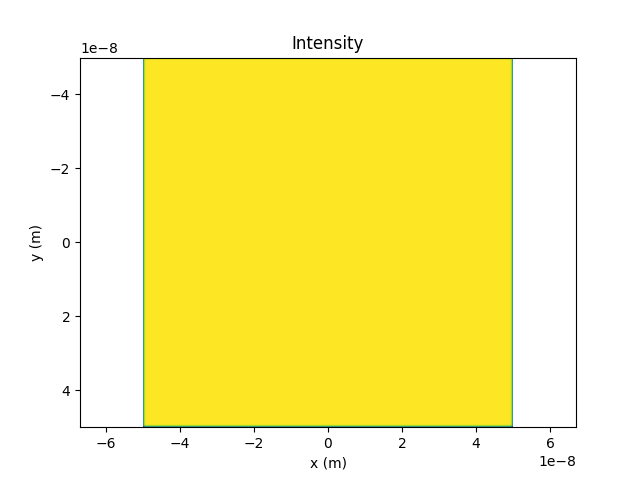

In [57]:
plt.figure()
plt.title('Intensity')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.imshow(np.abs(E_in), extent=input_extent)


In [58]:
run_to_end_vmapped = jax.vmap(run_to_end, in_axes=(0, None))

In [59]:
ray_out = run_to_end_vmapped(rays_in, [biprism])

/nobackup/dl277493/.pyenv/versions/JaxGym/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:5732: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  return array(a, dtype=dtype, copy=bool(copy), order=order, device=device)


In [60]:
E_biprism = evaluate_gaussians_gpu_kernel_wrapper(ray_out, input_grid)

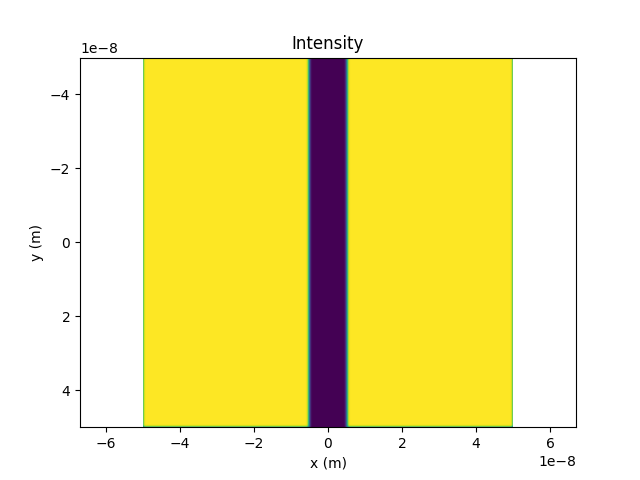

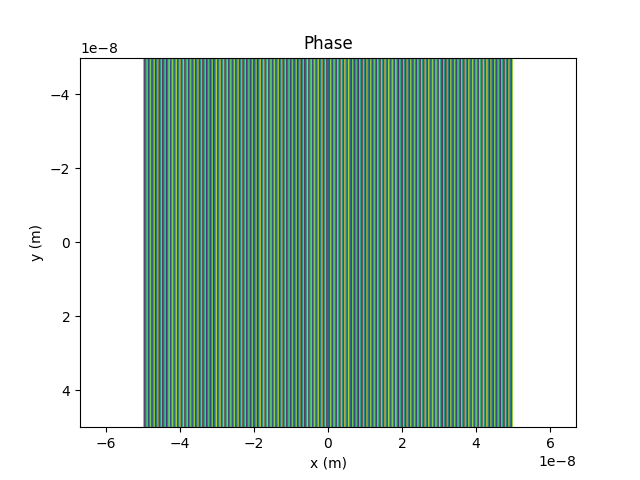

In [61]:
plt.figure()
plt.title('Intensity')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.imshow(np.abs(E_biprism), extent=input_extent)

plt.figure()
plt.title('Phase')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.imshow(np.angle(E_biprism), extent=input_extent)

In [62]:
ray_out = run_to_end_vmapped(rays_in, [biprism, output_grid])
E_out = evaluate_gaussians_gpu_kernel_wrapper(ray_out, output_grid)

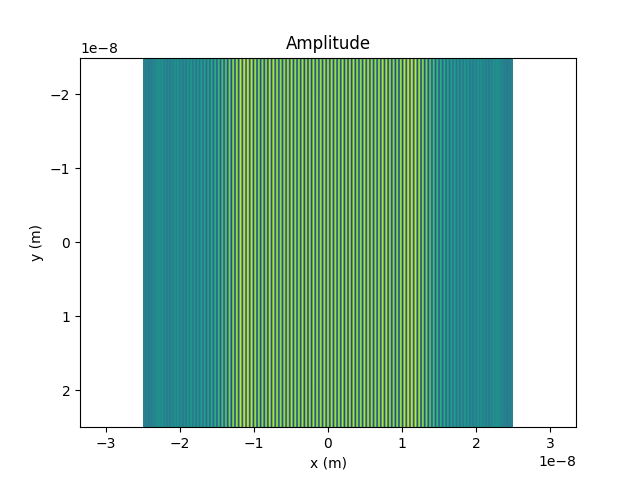

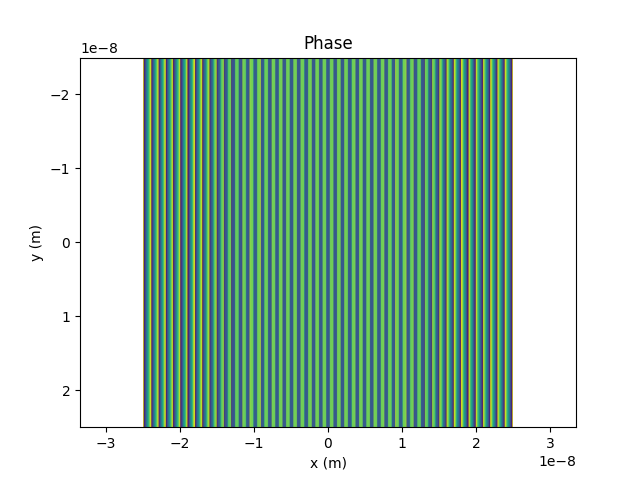

In [63]:
plt.figure()
plt.title('Amplitude')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
# plt.plot(ray_out.x, ray_out.y, 'r.', markersize=0.5)
plt.imshow(np.abs(E_out), extent=output_extent)

plt.figure()
plt.title('Phase')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.imshow(np.angle(E_out), extent=output_extent)